In [2]:
import sys
import os
from pathlib import Path

# Add parent directory to path if needed
# For Jupyter notebooks, use explicit path based on common notebook location
if '__file__' in globals():
    repo_root = Path(__file__).absolute().parents[1]
else:
    # Try to find repo root by looking for common directories
    cwd = Path.cwd()
    # If we're in sam/examples, go up 2 levels
    if (cwd / "sam" / "examples").exists() or cwd.name == "examples":
        repo_root = cwd.parent.parent
    # If we're in the repo root, use it directly
    elif (cwd / "mode").exists() and (cwd / "LIBERO").exists():
        repo_root = cwd
    # Otherwise, try parent directory
    else:
        repo_root = cwd.parent if (cwd.parent / "mode").exists() else cwd

sys.path.insert(0, str(repo_root))
print(f"✓ Repo root set to: {repo_root}")

# Add LIBERO submodule to path so 'libero' module can be imported
libero_repo_dir = repo_root / "LIBERO"
if libero_repo_dir.exists():
    sys.path.insert(0, str(libero_repo_dir))
    # Also set PYTHONPATH environment variable for subprocesses
    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = f"{libero_repo_dir}:{current_pythonpath}" if current_pythonpath else str(libero_repo_dir)

# Add local SAM3 to path (prioritize local over site-packages)
local_sam3_dir = repo_root / "sam" / "sam3"
if local_sam3_dir.exists():
    sys.path.insert(0, str(local_sam3_dir))
    print(f"✓ Added local SAM3 to path: {local_sam3_dir}")

import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import types

# Import MS-ILLM utilities
from mode.evaluation.utils import (
    load_msillm_from_torchhub,
    extract_compression_modules,
    patch_modeagent_embed_visual_obs_for_msillm,
    _clip_mean_std
)
from omegaconf import DictConfig, OmegaConf

print("Basic imports completed")


✓ Repo root set to: /home/hjkim/MoDE_Diffusion_Policy
✓ Added local SAM3 to path: /home/hjkim/MoDE_Diffusion_Policy/sam/sam3


/home/hjkim/.conda/envs/sam3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hjkim/.conda/envs/sam3/lib/python3.12/site-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Basic imports completed


In [3]:
# MS-ILLM Model Setup and Checkpoint Loading
# Load MS-ILLM model and weights from checkpoint

msillm_available = False
msillm_model = None
msillm_encoder = None
msillm_decoder = None

# Checkpoint path
checkpoint_path = Path("/home/hjkim/MoDE_Diffusion_Policy/saved_models/msillm-NeuralCompression_main-msillm_quality_vlo1_epoch=79.ckpt")

print("="*60)
print("MS-ILLM Model Initialization")
print("="*60)

try:
    # Load MS-ILLM model structure from torch hub
    # Create a minimal config for MS-ILLM
    msillm_cfg = OmegaConf.create({
        'msillm': {
            'hub_repo': 'facebookresearch/NeuralCompression:main',
            'entrypoint': 'msillm_quality_1',
            'pretrained': True
        }
    })
    
    print("\n1. Loading MS-ILLM model structure from torch hub...")
    msillm_model, msillm_decoder = load_msillm_from_torchhub(msillm_cfg)
    
    if msillm_model is None:
        raise ValueError("Failed to load MS-ILLM model from torch hub")
    
    msillm_encoder, _ = extract_compression_modules(msillm_model)
    msillm_available = True
    print(f"✓ MS-ILLM model structure loaded successfully")
    print(f"  - Model type: {type(msillm_model).__name__}")
    print(f"  - Encoder available: {msillm_encoder is not None}")
    print(f"  - Decoder available: {msillm_decoder is not None}")
    
    # Load weights from checkpoint
    if checkpoint_path.exists():
        print(f"\n2. Loading weights from checkpoint: {checkpoint_path}")
        
        # Load checkpoint
        checkpoint = torch.load(checkpoint_path.as_posix(), map_location='cpu', weights_only=False)
        
        # Extract MS-ILLM weights from checkpoint
        state_dict = checkpoint.get('state_dict', checkpoint)
        
        # Find all MS-ILLM related keys
        msillm_keys = [k for k in state_dict.keys() if k.startswith('msillm_model.')]
        
        if len(msillm_keys) > 0:
            print(f"  Found {len(msillm_keys)} MS-ILLM parameter keys in checkpoint")
            
            # Create a state dict with keys matching the loaded model
            msillm_state_dict = {}
            for key in msillm_keys:
                # Remove 'msillm_model.' prefix
                new_key = key.replace('msillm_model.', '')
                msillm_state_dict[new_key] = state_dict[key]
            
            # Load weights into model
            missing_keys, unexpected_keys = msillm_model.load_state_dict(msillm_state_dict, strict=False)
            
            if missing_keys:
                print(f"  ⚠ Missing keys (not loaded): {len(missing_keys)} keys")
                if len(missing_keys) <= 10:
                    print(f"    {missing_keys}")
                else:
                    print(f"    {missing_keys[:10]} ... and {len(missing_keys) - 10} more")
            else:
                print(f"  ✓ All keys matched successfully")
            
            if unexpected_keys:
                print(f"  ⚠ Unexpected keys (ignored): {len(unexpected_keys)} keys")
                if len(unexpected_keys) <= 10:
                    print(f"    {unexpected_keys}")
                else:
                    print(f"    {unexpected_keys[:10]} ... and {len(unexpected_keys) - 10} more")
            
            # Load checkpoint info if available
            if 'epoch' in checkpoint:
                print(f"  ✓ Checkpoint epoch: {checkpoint['epoch']}")
            if 'global_step' in checkpoint:
                print(f"  ✓ Checkpoint global_step: {checkpoint['global_step']}")
            
            print(f"  ✓ MS-ILLM weights loaded from checkpoint")
        else:
            print(f"  ⚠ No MS-ILLM keys found in checkpoint, using pretrained weights")
    else:
        print(f"\n2. Checkpoint not found at {checkpoint_path}")
        print(f"  Using pretrained weights from torch hub")
    
    # Set model to evaluation mode
    msillm_model.eval()
    
    # Set compression mode (moves entropy bottlenecks to CPU if available)
    if hasattr(msillm_model, 'update_tensor_devices'):
        try:
            msillm_model.update_tensor_devices('compress')
            print(f"\n3. ✓ MS-ILLM set to compression mode")
        except Exception as e:
            print(f"\n3. ⚠ Failed to set compression mode: {e}")
    
    print(f"\n{'='*60}")
    print(f"MS-ILLM is ready for compression!")
    print(f"{'='*60}")
    
except ImportError as e:
    print(f"✗ MS-ILLM ImportError: {e}")
    print("  Make sure mode.evaluation.utils is available")
    import traceback
    traceback.print_exc()
except Exception as e:
    print(f"✗ MS-ILLM initialization failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()
    msillm_model = None
    msillm_encoder = None
    msillm_decoder = None

print(f"\nmsillm_available = {msillm_available}")

MS-ILLM Model Initialization

1. Loading MS-ILLM model structure from torch hub...


/home/hjkim/.cache/torch/hub/facebookresearch_NeuralCompression_main/neuralcompression/__init__.py:21: UserWarning: Could not retrieve neuralcompression version!
  warnings.warn("Could not retrieve neuralcompression version!")


✓ MS-ILLM model structure loaded successfully
  - Model type: HiFiCAutoencoder
  - Encoder available: True
  - Decoder available: True

2. Loading weights from checkpoint: /home/hjkim/MoDE_Diffusion_Policy/saved_models/msillm-NeuralCompression_main-msillm_quality_vlo1_epoch=79.ckpt
  Found 163 MS-ILLM parameter keys in checkpoint
  ✓ All keys matched successfully
  ✓ Checkpoint epoch: 79
  ✓ Checkpoint global_step: 43200
  ✓ MS-ILLM weights loaded from checkpoint

3. ✓ MS-ILLM set to compression mode

MS-ILLM is ready for compression!

msillm_available = True


In [10]:
# MS-ILLM Compression Functions
# Helper functions to compress/decompress images using MS-ILLM

def compress_image_with_msillm(image_tensor, resize_to_64_multiple=True, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Compress an image using MS-ILLM.
    
    Args:
        image_tensor: Image tensor in [0, 1] range, shape [C, H, W] or [B, C, H, W] or [B, T, C, H, W]
        resize_to_64_multiple: Whether to resize to multiple of 64 (required by MS-ILLM)
        device: Device to use for compression
    
    Returns:
        compressed: Compressed representation
        recon_tensor: Reconstructed image tensor in [0, 1] range
        original_shape: Original shape of the image
    """
    if not msillm_available or msillm_model is None:
        raise ValueError("MS-ILLM model is not available")
    
    # Store original shape and dimensions
    original_shape = image_tensor.shape
    if image_tensor.dim() == 3:  # [C, H, W]
        image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, C, H, W]
        squeeze_back = True
    elif image_tensor.dim() == 4:  # [B, C, H, W]
        image_tensor = image_tensor.unsqueeze(1)  # [B, 1, C, H, W]
        squeeze_back = False
    elif image_tensor.dim() == 5:  # [B, T, C, H, W]
        squeeze_back = False
    else:
        raise ValueError(f"Unsupported tensor shape: {image_tensor.shape}")
    
    # Ensure values are in [0, 1] range
    # IMPORTANT: MS-ILLM model weights may live on CPU (especially after update_tensor_devices('compress')).
    # We must place the input tensor on the SAME device as the model weights to avoid dtype/device mismatches.
    try:
        model_param_device = next(msillm_model.parameters()).device
    except StopIteration:
        model_param_device = torch.device(device)

    if isinstance(device, str):
        requested_device = torch.device(device)
    else:
        requested_device = device

    effective_device = model_param_device
    if requested_device.type == "cuda" and model_param_device.type != "cuda":
        # Keep it quiet but clear; notebook users can see this.
        print(f"[MS-ILLM] NOTE: model is on {model_param_device}, overriding requested device={requested_device} -> {effective_device}")

    image_tensor = image_tensor.clamp(0.0, 1.0).to(effective_device)
    
    b, t, c, h, w = image_tensor.shape
    image_bt = image_tensor.reshape(b * t, c, h, w)
    
    # Resize to multiple of 64 if needed
    resize_needed = False
    if resize_to_64_multiple:
        factor = 64
        if h % factor != 0 or w % factor != 0:
            new_h = ((h + factor - 1) // factor) * factor
            new_w = ((w + factor - 1) // factor) * factor
            image_bt_resized = F.interpolate(image_bt, size=(new_h, new_w), mode='bilinear', align_corners=False)
            resize_needed = True
        else:
            image_bt_resized = image_bt
    else:
        image_bt_resized = image_bt
    
    # Compress and decompress
    force_cpu = (effective_device.type == "cpu")
    with torch.no_grad():
        compressed = msillm_model.compress(image_bt_resized, force_cpu=force_cpu)
        recon_resized = msillm_model.decompress(compressed, force_cpu=force_cpu).clamp(0.0, 1.0)
    
    # Resize back to original size if needed
    if resize_needed:
        recon = F.interpolate(recon_resized, size=(h, w), mode='bilinear', align_corners=False)
    else:
        recon = recon_resized
    
    # Reshape back to original format
    recon = recon.reshape(b, t, c, h, w)
    
    if squeeze_back:
        recon = recon.squeeze(0).squeeze(0)  # [C, H, W]
    
    return compressed, recon, original_shape

def compress_numpy_image_with_msillm(image_np, resize_to_64_multiple=True, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Compress a numpy image using MS-ILLM.
    
    Args:
        image_np: Image as numpy array in [0, 255] uint8, shape [H, W, C]
        resize_to_64_multiple: Whether to resize to multiple of 64
        device: Device to use for compression
    
    Returns:
        compressed: Compressed representation
        recon_np: Reconstructed image as numpy array in [0, 255] uint8, shape [H, W, C]
    """
    # Convert numpy to tensor
    if image_np.dtype != np.uint8:
        if image_np.max() <= 1.0:
            image_np = (image_np * 255).astype(np.uint8)
        else:
            image_np = image_np.astype(np.uint8)

    # IMPORTANT: images coming from np.rot90 / slicing can have negative strides.
    # torch.from_numpy() does not support negative-stride arrays, so make it contiguous.
    image_np = np.ascontiguousarray(image_np)
    
    # Convert [H, W, C] to [C, H, W] and normalize to [0, 1]
    if image_np.ndim == 2 or (image_np.ndim == 3 and image_np.shape[2] == 1):
        # Grayscale
        if image_np.ndim == 3:
            image_np = image_np.squeeze(2)
        image_tensor = torch.from_numpy(image_np).float() / 255.0  # [H, W]
        image_tensor = image_tensor.unsqueeze(0)  # [1, H, W]
    else:
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0  # [C, H, W]
    
    # Compress
    compressed, recon_tensor, _ = compress_image_with_msillm(image_tensor, resize_to_64_multiple, device)
    
    # Convert back to numpy
    if recon_tensor.dim() == 2:  # [H, W]
        recon_np = (recon_tensor.cpu().numpy() * 255).astype(np.uint8)
    else:  # [C, H, W]
        recon_np = (recon_tensor.cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
        if recon_np.shape[2] == 1:
            recon_np = recon_np.squeeze(2)
    
    return compressed, recon_np

print("✓ MS-ILLM compression functions defined")
print("  - compress_image_with_msillm: Compress torch tensor images")
print("  - compress_numpy_image_with_msillm: Compress numpy array images")

✓ MS-ILLM compression functions defined
  - compress_image_with_msillm: Compress torch tensor images
  - compress_numpy_image_with_msillm: Compress numpy array images


In [11]:
# Import SAM3 (will use local version if available)
sam3_available = False
sam3_model = None
sam3_processor = None

try:
    # Remove site-packages sam3 from sys.modules if already imported
    if 'sam3' in sys.modules:
        del sys.modules['sam3']
        # Also remove submodules
        for key in list(sys.modules.keys()):
            if key.startswith('sam3.'):
                del sys.modules[key]
    
    from sam3.model_builder import build_sam3_image_model
    from sam3.model.sam3_image_processor import Sam3Processor
    sam3_available = True
    
    sam3_module = __import__('sam3')
    sam3_location = sam3_module.__file__
    print("✓ SAM3 imported successfully")
    print(f"  SAM3 module location: {sam3_location}")
    
    # Check if it's local or site-packages
    if '/sam/sam3' in sam3_location:
        print("  ✓ Using LOCAL SAM3 version")
    else:
        print("  ⚠ Using site-packages SAM3 version")
        
except ImportError as e:
    print(f"✗ SAM3 ImportError: {e}")
    print("  Install with: pip install sam3 or ensure local SAM3 is available")
except Exception as e:
    print(f"✗ SAM3 import failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Verify sam3_available
print(f"\nsam3_available = {sam3_available}")

✓ SAM3 imported successfully
  SAM3 module location: /home/hjkim/MoDE_Diffusion_Policy/sam/sam3/sam3/__init__.py
  ✓ Using LOCAL SAM3 version

sam3_available = True


In [13]:
# Load dataset using the same method as training_libero_msillm.py
import hydra
from hydra import compose, initialize_config_dir
from omegaconf import DictConfig, OmegaConf
from pytorch_lightning import seed_everything
from hydra.core.global_hydra import GlobalHydra

# Clear any existing Hydra instance
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Set environment variables (similar to training script)
os.environ['HYDRA_FULL_ERROR'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

# Initialize Hydra with absolute config directory path
# Use initialize_config_dir() which accepts absolute paths (unlike initialize())
config_dir = (repo_root / "conf").resolve()
print(f"Initializing Hydra with config directory: {config_dir}")

# Initialize with absolute path - initialize_config_dir() accepts it
initialize_config_dir(config_dir=str(config_dir), version_base=None)

# Compose config using the same config name as training_libero_msillm.py
cfg = compose(config_name="config_libero_msillm")

# Set seed (same as training script)
seed_everything(cfg.seed, workers=True)

# Instantiate datamodule (same as training_libero_msillm.py line 660)
datamodule = hydra.utils.instantiate(cfg.datamodule)

print(f"DataModule initialized: {type(datamodule).__name__}")
print(f"Benchmark name: {getattr(datamodule, 'benchmark_name', 'N/A')}")

# Get data directory info from config
if hasattr(cfg, 'root_data_dir'):
    print(f"Root data dir (from config): {cfg.root_data_dir}")
elif hasattr(cfg.datamodule, 'datasets') and hasattr(cfg.datamodule.datasets.lang_dataset, 'custom_data_path'):
    print(f"Custom data path: {cfg.datamodule.datasets.lang_dataset.custom_data_path}")
else:
    # Use LIBERO's default path
    try:
        from libero.libero import get_libero_path
        default_path = get_libero_path("datasets")
        print(f"Default LIBERO datasets path: {default_path}")
    except:
        print("Using default LIBERO datasets path (not available yet)")

# Prepare data and setup to access actual dataset
print("\nPreparing data and setting up datamodule...")
datamodule.prepare_data()
datamodule.setup()

# Get a sample batch from validation dataloader
print("Loading sample batch from dataset...")
val_dataloader = datamodule.val_dataloader()
if isinstance(val_dataloader, dict) and "lang" in val_dataloader:
    sample_batch = next(iter(val_dataloader["lang"]))
    print(f"\nSample batch keys: {sample_batch.keys()}")
    print(f"Sample batch shapes:")
    for k, v in sample_batch.items():
        if isinstance(v, torch.Tensor):
            print(f"  {k}: {v.shape}")
        elif isinstance(v, dict):
            print(f"  {k} (dict keys): {v.keys()}")
            for subk, subv in v.items():
                if isinstance(subv, torch.Tensor):
                    print(f"    {subk}: {subv.shape}")

print("Dataset loading completed")
print(f"\nYou can now use 'datamodule' and 'cfg' variables in subsequent cells.")


Global seed set to 242


Initializing Hydra with config directory: /home/hjkim/MoDE_Diffusion_Policy/conf
DataModule initialized: LiberoDataModule
Benchmark name: libero_10
Root data dir (from config): ./data

Preparing data and setting up datamodule...
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

============= Initialized Observation Utils with Obs Spec =============

using obs modality: rgb with keys: ['eye_in_hand_rgb', 'agentview_rgb']
using obs modality: low_dim with keys: ['joint_states', 'gripper_states']
SequenceDataset: loading dataset into memory...
100%|██████████| 50/50 [00:00<00:00, 1178.12it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 50/50 [00:00<00:00, 1294.47it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 50/50 [00:00<00:00, 1290.42it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 50/50 [00:00<00:00, 1250.91it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 50/50 [00:00<00:00, 1277.79it/s]
Seque

In [ ]:
# Extract images from the sample batch and convert to numpy format for visualization
def extract_image_from_batch(batch, image_key="rgb_static", batch_idx=0, time_idx=0):
    """
    Extract image from batch and convert to numpy array for visualization.
    
    Args:
        batch: Batch dictionary from dataloader
        image_key: Key for image type ("rgb_static" or "rgb_gripper")
        batch_idx: Batch index (default: 0)
        time_idx: Time step index (default: 0)
    
    Returns:
        numpy array image in (H, W, C) format, uint8
    """
    # Images are typically in batch['rgb_obs'][image_key]
    # Shape: (B, T, C, H, W) or (B, C, H, W)
    if 'rgb_obs' in batch and image_key in batch['rgb_obs']:
        img_tensor = batch['rgb_obs'][image_key]
    elif image_key in batch:
        img_tensor = batch[image_key]
    else:
        raise KeyError(f"Image key '{image_key}' not found in batch. Available keys: {batch.keys()}")
    
    # Convert to numpy
    if isinstance(img_tensor, torch.Tensor):
        img_np = img_tensor.detach().cpu().numpy()
    else:
        img_np = img_tensor

    # Handle different tensor shapes: (B, T, C, H, W) or (B, C, H, W) or (C, H, W)
    if img_np.ndim == 5:  # (B, T, C, H, W)
        img_np = img_np[batch_idx, time_idx]
    elif img_np.ndim == 4:  # (B, C, H, W)
        img_np = img_np[batch_idx]
    elif img_np.ndim == 3:  # (C, H, W)
        pass  # Already in correct format
    
    # Convert from (C, H, W) to (H, W, C)
    if img_np.shape[0] == 3 or img_np.shape[0] == 1:
        img_np = np.transpose(img_np, (1, 2, 0))
    # Handle normalization: if values are in [0, 1], convert to [0, 255]
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)
    
    img_np = np.rot90(img_np, k=2, axes=(0, 1))

    # Handle grayscale to RGB conversion if needed
    if img_np.ndim == 2 or (img_np.ndim == 3 and img_np.shape[2] == 1):
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif img_np.shape[2] == 4:  # RGBA to RGB
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)
    
    return img_np

# Extract static and gripper images from sample batch
static_img = extract_image_from_batch(sample_batch, image_key="rgb_static", batch_idx=0, time_idx=0)
gripper_img = extract_image_from_batch(sample_batch, image_key="rgb_gripper", batch_idx=0, time_idx=0)

print(f"Static image shape: {static_img.shape}, dtype: {static_img.dtype}, range: [{static_img.min()}, {static_img.max()}]")
print(f"Gripper image shape: {gripper_img.shape}, dtype: {gripper_img.dtype}, range: [{gripper_img.min()}, {gripper_img.max()}]")

# Get language text if available
lang_text = sample_batch.get('lang_text', 'No language text')
if isinstance(lang_text, (list, tuple)):
    lang_text = lang_text[0] if len(lang_text) > 0 else 'No language text'
print(f"Language instruction: {lang_text}")

# Visualize the images
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(static_img)
axes[0].set_title('Static Camera (Agent View)')
axes[0].axis('off')

axes[1].imshow(gripper_img)
axes[1].set_title('Gripper Camera (Eye-in-Hand)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Images extracted successfully! Use 'static_img' and 'gripper_img' variables for SAM3.")


Static image shape: (224, 224, 3), dtype: uint8, range: [0, 244]
Gripper image shape: (112, 112, 3), dtype: uint8, range: [0, 156]
Language instruction: put both the alphabet soup and the tomato sauce in the basket


AttributeError: 'RcParams' object has no attribute '_get'

In [ ]:
# SAM3 Image Segmentation on LIBERO Dataset Images
# Based on SAM3 example code from sam/sam3/examples/

if not sam3_available:
    print("⚠ SAM3 is not available. Please install with: pip install sam3")
    print("   Or check if sam3_available is True in Cell 1")
else:
    print("✓ SAM3 is available. Initializing SAM3 image model...")

    # Initialize SAM3 image model (loads from HuggingFace automatically)
    try:
        sam3_model = build_sam3_image_model()

        # NOTE: Sam3Processor filters predictions by confidence_threshold (default=0.5).
        # For small/low-res robot images, 0.5 often yields 0 detections.
        sam3_processor = Sam3Processor(sam3_model, confidence_threshold=0.05)
        print("✓ SAM3 model and processor initialized successfully!")
        print(f"  Sam3Processor.confidence_threshold = {sam3_processor.confidence_threshold}")
    except Exception as e:
        print(f"✗ Error initializing SAM3: {e}")
        import traceback
        traceback.print_exc()
        sam3_model = None
        sam3_processor = None


✓ SAM3 is available. Initializing SAM3 image model...
✓ SAM3 model and processor initialized successfully!
  Sam3Processor.confidence_threshold = 0.05


In [ ]:
# Convert LIBERO dataset images to PIL Image format and segment with SAM3
# Why you saw 0 masks:
# - Sam3Processor filters detections by `confidence_threshold` (default 0.5).
# - Also, full instructions ("put X in Y") are often worse prompts than object phrases ("alphabet soup").

import re

if sam3_available and sam3_processor is not None:
    # Helper function to convert numpy array to PIL Image
    def numpy_to_pil(img_np):
        """Convert numpy array (H, W, C) uint8 to PIL Image"""
        if img_np.dtype != np.uint8:
            if img_np.max() <= 1.0:
                img_np = (img_np * 255).astype(np.uint8)
            else:
                img_np = img_np.astype(np.uint8)
        # Ensure RGB format
        if img_np.ndim == 2 or (img_np.ndim == 3 and img_np.shape[2] == 1):
            img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        elif img_np.shape[2] == 4:  # RGBA to RGB
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)
        return Image.fromarray(img_np)

    def build_prompt_candidates(instruction: str):
        """Heuristic: include full instruction + object-ish phrases after 'the ...'."""
        if not isinstance(instruction, str):
            instruction = str(instruction)
        base = instruction.strip()
        cands = []
        #if base:
        #    cands.append(base)

        # Extract phrases like: "the alphabet soup" -> "alphabet soup"
        low = base.lower()
        phrases = re.findall(
            r"\bthe ([a-z0-9\- ]+?)(?=\s+(?:and|in|on|into|onto|to)\b|\s*[\.,;:]|$)",
            low,
        )
        for p in phrases:
            p = p.strip()
            if p and p not in cands:
                cands.append(p)

        # If we found nothing, fall back to a very generic visual query
        if not cands:
            cands = ["object"]

        return cands

    def run_sam3_on_image(image_pil, prompts, thresholds, label="image"):
        """Try all prompt candidates and return combined results from all prompts."""
        state = sam3_processor.set_image(image_pil)
        print(f"✓ {label}: image set\n")

        all_results = []
        
        # Try all prompt candidates
        for prompt_idx, prompt in enumerate(prompts):
            print(f"  [{prompt_idx + 1}/{len(prompts)}] Trying prompt: {prompt!r}")
            prompt_results = []
            
            for thr in thresholds:
                sam3_processor.confidence_threshold = float(thr)
                out = sam3_processor.set_text_prompt(prompt=prompt, state=state)
                n = len(out["scores"])
                
                if n > 0:
                    prompt_results.append({
                        'threshold': thr,
                        'masks': out["masks"],
                        'boxes': out["boxes"],
                        'scores': out["scores"],
                        'num_masks': n
                    })
                    print(f"    ✓ threshold={thr:.2f}: {n} masks (score range: [{out['scores'].min():.3f}, {out['scores'].max():.3f}])")
                else:
                    print(f"    ✗ threshold={thr:.2f}: 0 masks")
            
            # Keep the best result for this prompt (highest threshold with detections, or most masks)
            if prompt_results:
                # Prefer higher threshold results, but if multiple exist, take one with most masks
                best_for_prompt = max(prompt_results, key=lambda x: (x['threshold'], x['num_masks']))
                best_for_prompt['prompt'] = prompt
                all_results.append(best_for_prompt)
                print(f"    → Selected: threshold={best_for_prompt['threshold']:.2f}, {best_for_prompt['num_masks']} masks\n")
            else:
                print(f"    → No detections for this prompt\n")
        
        # Combine all results
        if all_results:
            print(f"  Summary: Found results for {len(all_results)}/{len(prompts)} prompts")
            
            # Combine masks, boxes, and scores from all prompts
            combined_masks = []
            combined_boxes = []
            combined_scores = []
            
            for result in all_results:
                masks = result['masks']
                boxes = result['boxes']
                scores = result['scores']
                
                # Handle mask shape: masks can be (N, 1, H, W) or (N, H, W)
                for i in range(len(scores)):
                    mask = masks[i]
                    if isinstance(mask, torch.Tensor):
                        # Ensure mask keeps its shape (should be (1, H, W) or (H, W))
                        combined_masks.append(mask.clone())
                    else:
                        combined_masks.append(mask.copy())
                    
                    if isinstance(boxes, torch.Tensor):
                        combined_boxes.append(boxes[i].clone())
                    else:
                        combined_boxes.append(boxes[i].copy())
                    
                    if isinstance(scores, torch.Tensor):
                        combined_scores.append(scores[i].clone())
                    else:
                        combined_scores.append(scores[i].copy())
            
            # Convert back to tensors if needed
            if len(combined_masks) > 0:
                if isinstance(all_results[0]['masks'], torch.Tensor):
                    # Stack masks preserving their shape
                    combined_masks_tensor = torch.stack(combined_masks)
                    combined_boxes_tensor = torch.stack(combined_boxes)
                    combined_scores_tensor = torch.stack(combined_scores)
                    
                    return {
                        'masks': combined_masks_tensor,
                        'boxes': combined_boxes_tensor,
                        'scores': combined_scores_tensor,
                        'prompt_results': all_results
                    }
                else:
                    # For numpy arrays, stack them
                    try:
                        combined_masks_array = np.stack(combined_masks)
                        combined_boxes_array = np.stack(combined_boxes)
                        combined_scores_array = np.stack(combined_scores)
                    except:
                        # If shapes don't match, use list
                        combined_masks_array = combined_masks
                        combined_boxes_array = np.array(combined_boxes)
                        combined_scores_array = np.array(combined_scores)
                    
                    return {
                        'masks': combined_masks_array,
                        'boxes': combined_boxes_array,
                        'scores': combined_scores_array,
                        'prompt_results': all_results
                    }
        
        # If no results, return empty result (use device from processor)
        print(f"  Summary: No detections for any prompt")
        device = sam3_processor.device
        return {
            'masks': torch.empty((0, 1, 1, 1), device=device, dtype=torch.bool),
            'boxes': torch.empty((0, 4), device=device, dtype=torch.float32),
            'scores': torch.empty((0,), device=device, dtype=torch.float32),
            'prompt_results': []
        }

    # Convert static and gripper images to PIL Image
    static_pil = numpy_to_pil(static_img)
    gripper_pil = numpy_to_pil(gripper_img)

    print(f"Static image size: {static_pil.size}")
    print(f"Gripper image size: {gripper_pil.size}")
    print(f"Language instruction: {lang_text}")

    prompt_candidates = build_prompt_candidates(lang_text)
    print(f"Prompt candidates: {prompt_candidates}")

    # Try a small ladder of thresholds
    thresholds = [sam3_processor.confidence_threshold, 0.10, 0.05]

    print("\n" + "="*60)
    print("Processing Static Image with SAM3")
    print("="*60)
    try:
        output_static = run_sam3_on_image(static_pil, prompt_candidates, thresholds, label="static")
        masks_static = output_static["masks"]
        boxes_static = output_static["boxes"]
        scores_static = output_static["scores"]
        prompt_results_static = output_static.get("prompt_results", [])
        
        # Print summary
        if len(masks_static) > 0:
            if isinstance(scores_static, torch.Tensor):
                print(f"\n  Final combined results: {len(masks_static)} masks, score range: [{scores_static.min():.3f}, {scores_static.max():.3f}]")
            else:
                print(f"\n  Final combined results: {len(masks_static)} masks, score range: [{scores_static.min():.3f}, {scores_static.max():.3f}]")
        else:
            print(f"\n  Final combined results: 0 masks")
    except Exception as e:
        print(f"✗ Error processing static image: {e}")
        import traceback
        traceback.print_exc()
        masks_static = None
        boxes_static = None
        scores_static = None
        prompt_results_static = []

    print("\n" + "="*60)
    print("Processing Gripper Image with SAM3")
    print("="*60)
    try:
        output_gripper = run_sam3_on_image(gripper_pil, prompt_candidates, thresholds, label="gripper")
        masks_gripper = output_gripper["masks"]
        boxes_gripper = output_gripper["boxes"]
        scores_gripper = output_gripper["scores"]
        prompt_results_gripper = output_gripper.get("prompt_results", [])
        
        # Print summary
        if len(masks_gripper) > 0:
            if isinstance(scores_gripper, torch.Tensor):
                print(f"\n  Final combined results: {len(masks_gripper)} masks, score range: [{scores_gripper.min():.3f}, {scores_gripper.max():.3f}]")
            else:
                print(f"\n  Final combined results: {len(masks_gripper)} masks, score range: [{scores_gripper.min():.3f}, {scores_gripper.max():.3f}]")
        else:
            print(f"\n  Final combined results: 0 masks")
    except Exception as e:
        print(f"✗ Error processing gripper image: {e}")
        import traceback
        traceback.print_exc()
        masks_gripper = None
        boxes_gripper = None
        scores_gripper = None
        prompt_results_gripper = []

    print("\n✓ SAM3 processing completed!")
    print("You can now use 'masks_static', 'boxes_static', 'scores_static' and")
    print("'masks_gripper', 'boxes_gripper', 'scores_gripper' for visualization.")

    # ------------------------------------------------------------
    # (NEW) SAM3 segmentation on MS-ILLM compressed reconstructions
    # ------------------------------------------------------------
    static_comp_np = None
    gripper_comp_np = None
    static_comp_pil = None
    gripper_comp_pil = None

    masks_static_comp = None
    boxes_static_comp = None
    scores_static_comp = None
    prompt_results_static_comp = []

    masks_gripper_comp = None
    boxes_gripper_comp = None
    scores_gripper_comp = None
    prompt_results_gripper_comp = []

    if 'msillm_available' in globals() and msillm_available:
        try:
            print("\n" + "="*60)
            print("MS-ILLM Compression + SAM3 on Compressed Reconstructions")
            print("="*60)

            # Compress/decompress the two camera images (reconstruction returned as uint8 numpy)
            _, static_comp_np = compress_numpy_image_with_msillm(static_img, resize_to_64_multiple=True)
            _, gripper_comp_np = compress_numpy_image_with_msillm(gripper_img, resize_to_64_multiple=True)

            static_comp_pil = numpy_to_pil(static_comp_np)
            gripper_comp_pil = numpy_to_pil(gripper_comp_np)

            print(f"Compressed static image size: {static_comp_pil.size}")
            print(f"Compressed gripper image size: {gripper_comp_pil.size}")

            # Reuse prompt_candidates/thresholds from above
            print("\n" + "="*60)
            print("Processing COMPRESSED Static Image with SAM3")
            print("="*60)
            out_static_comp = run_sam3_on_image(
                static_comp_pil,
                prompt_candidates,
                thresholds,
                label="static(compressed)",
            )
            masks_static_comp = out_static_comp["masks"]
            boxes_static_comp = out_static_comp["boxes"]
            scores_static_comp = out_static_comp["scores"]
            prompt_results_static_comp = out_static_comp.get("prompt_results", [])

            print("\n" + "="*60)
            print("Processing COMPRESSED Gripper Image with SAM3")
            print("="*60)
            out_gripper_comp = run_sam3_on_image(
                gripper_comp_pil,
                prompt_candidates,
                thresholds,
                label="gripper(compressed)",
            )
            masks_gripper_comp = out_gripper_comp["masks"]
            boxes_gripper_comp = out_gripper_comp["boxes"]
            scores_gripper_comp = out_gripper_comp["scores"]
            prompt_results_gripper_comp = out_gripper_comp.get("prompt_results", [])

            print("\n✓ Compressed-image SAM3 processing completed!")

        except Exception as e:
            print(f"✗ Failed compressed-image segmentation: {type(e).__name__}: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("\nℹ MS-ILLM is not available; skipping compressed-image segmentation.")
else:
    print("⚠ SAM3 is not available. Please initialize SAM3 in the previous cell.")


Static image size: (224, 224)
Gripper image size: (112, 112)
Language instruction: put both the alphabet soup and the tomato sauce in the basket
Prompt candidates: ['alphabet soup', 'tomato sauce', 'basket']

Processing Static Image with SAM3
✓ static: image set

  [1/3] Trying prompt: 'alphabet soup'
    ✓ threshold=0.05: 2 masks (score range: [0.081, 0.088])
    ✗ threshold=0.10: 0 masks
    ✓ threshold=0.05: 2 masks (score range: [0.081, 0.088])
    → Selected: threshold=0.05, 2 masks

  [2/3] Trying prompt: 'tomato sauce'
    ✓ threshold=0.05: 4 masks (score range: [0.056, 0.067])
    ✗ threshold=0.10: 0 masks
    ✓ threshold=0.05: 4 masks (score range: [0.056, 0.067])
    → Selected: threshold=0.05, 4 masks

  [3/3] Trying prompt: 'basket'
    ✓ threshold=0.05: 4 masks (score range: [0.050, 0.405])
    ✓ threshold=0.10: 1 masks (score range: [0.405, 0.405])
    ✓ threshold=0.05: 4 masks (score range: [0.050, 0.405])
    → Selected: threshold=0.10, 1 masks

  Summary: Found results


Visualizing static image segmentation results...


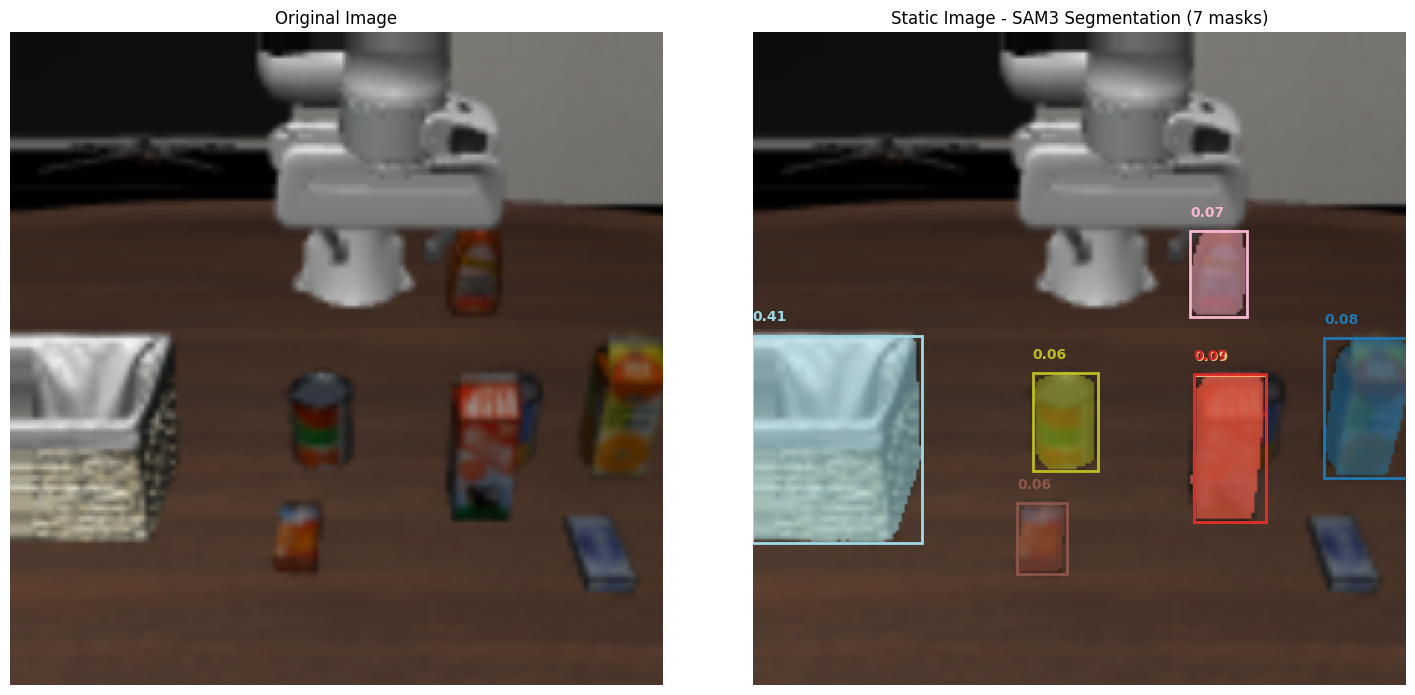


Visualizing gripper image segmentation results...


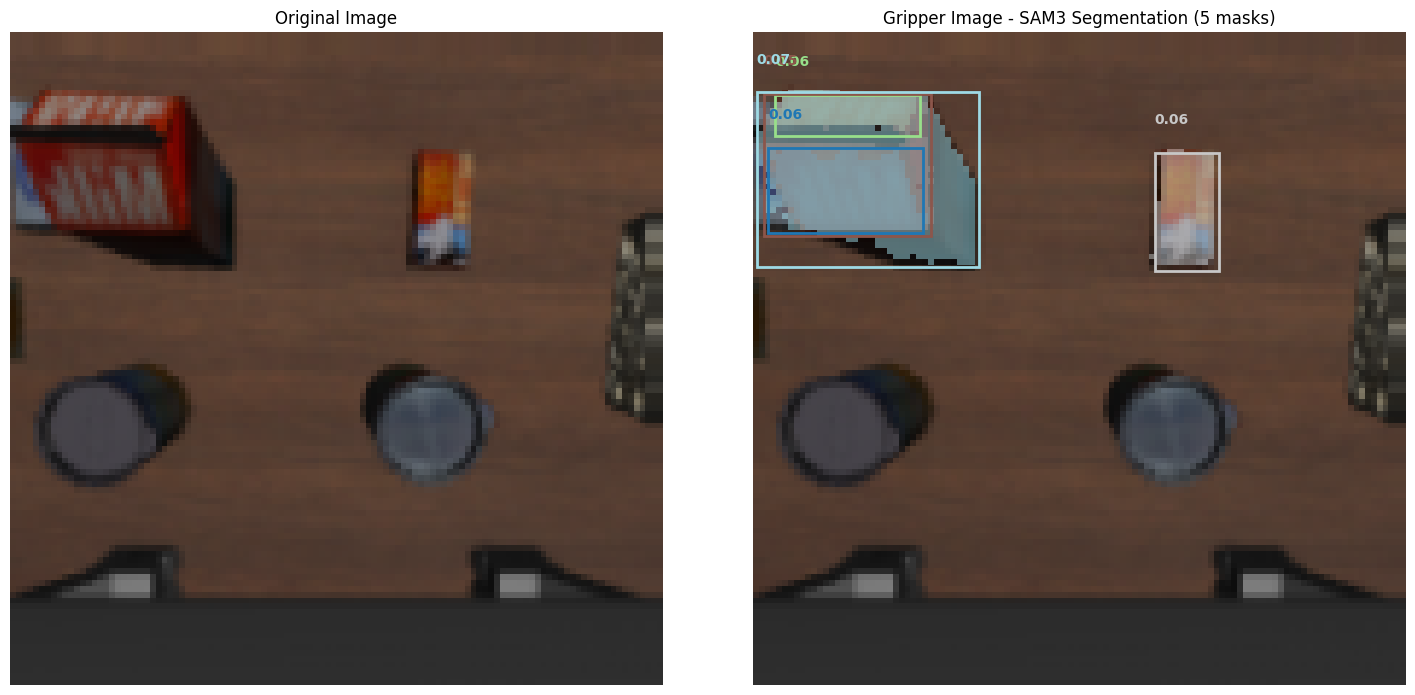


Creating side-by-side comparison...


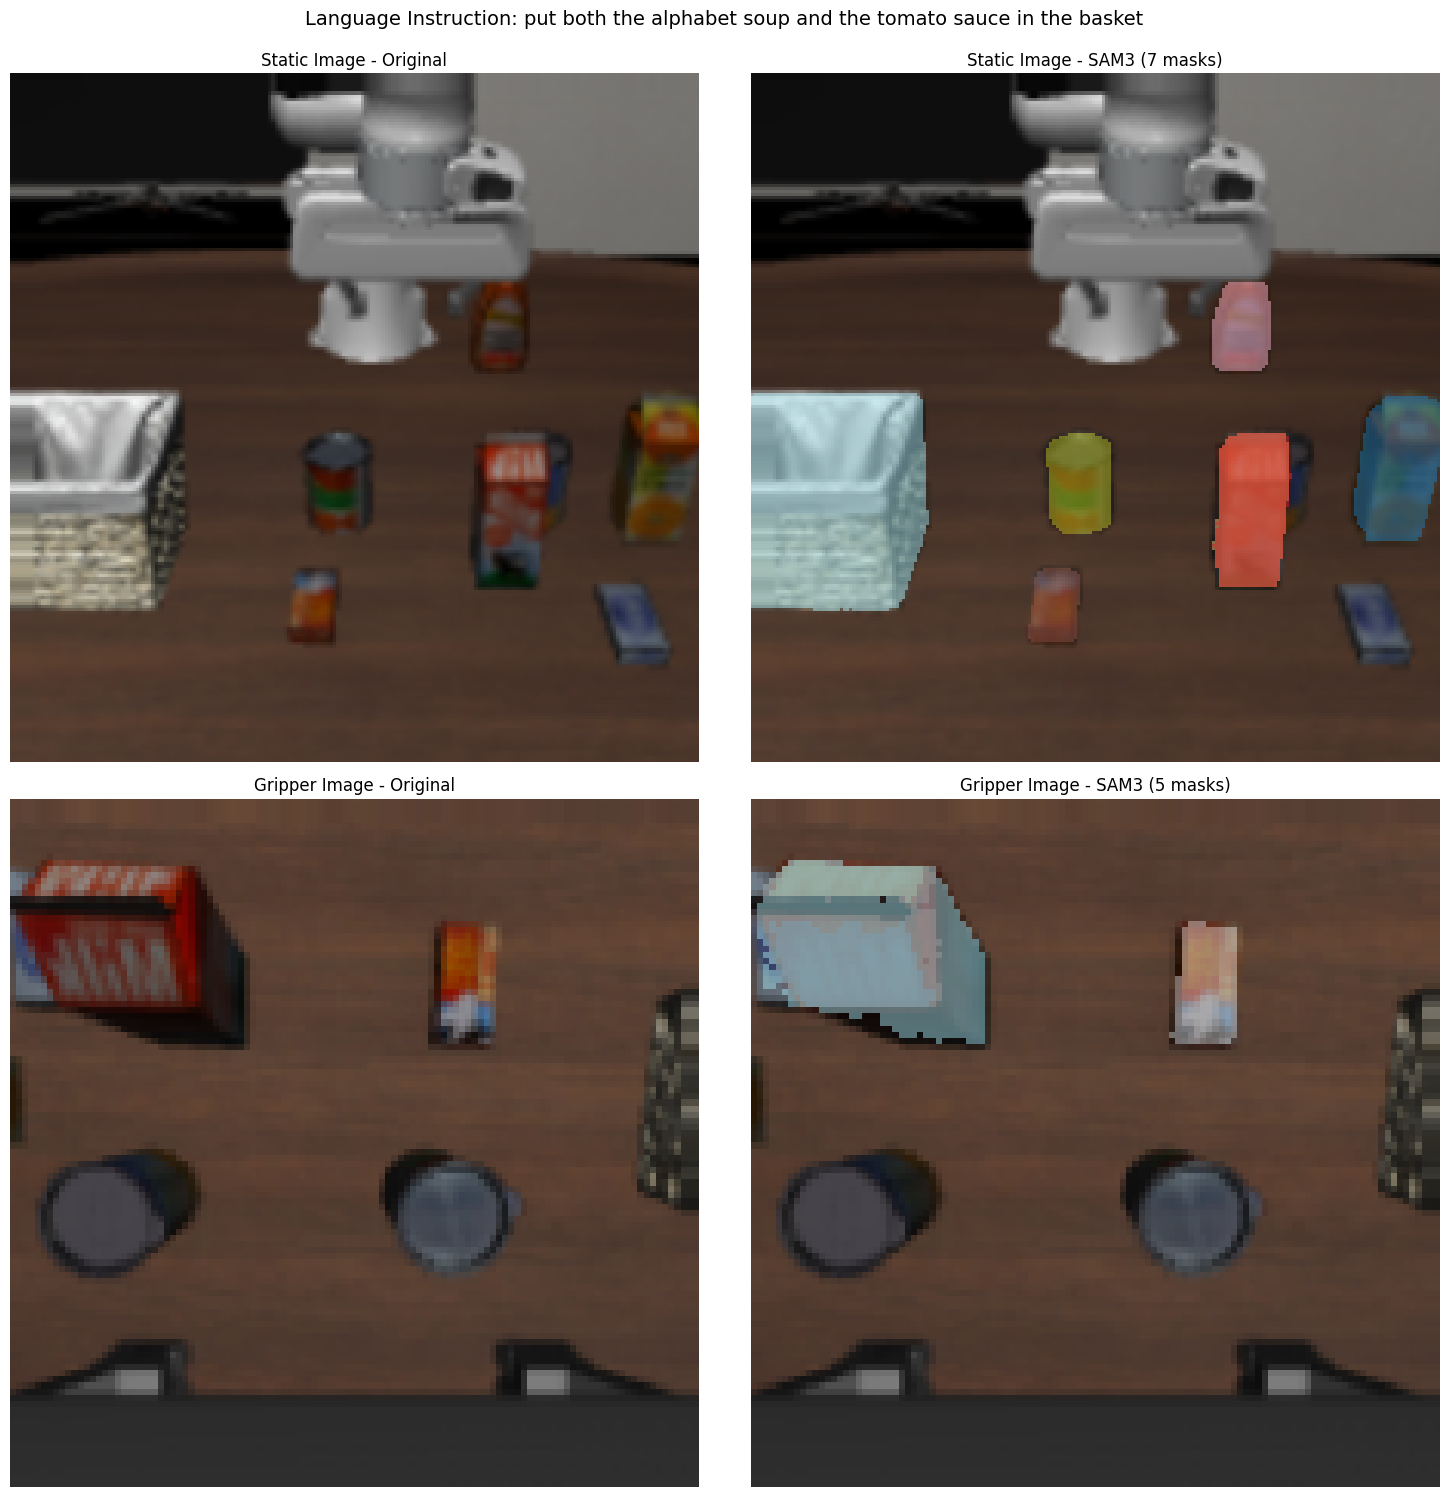


Creating original vs compressed comparison...


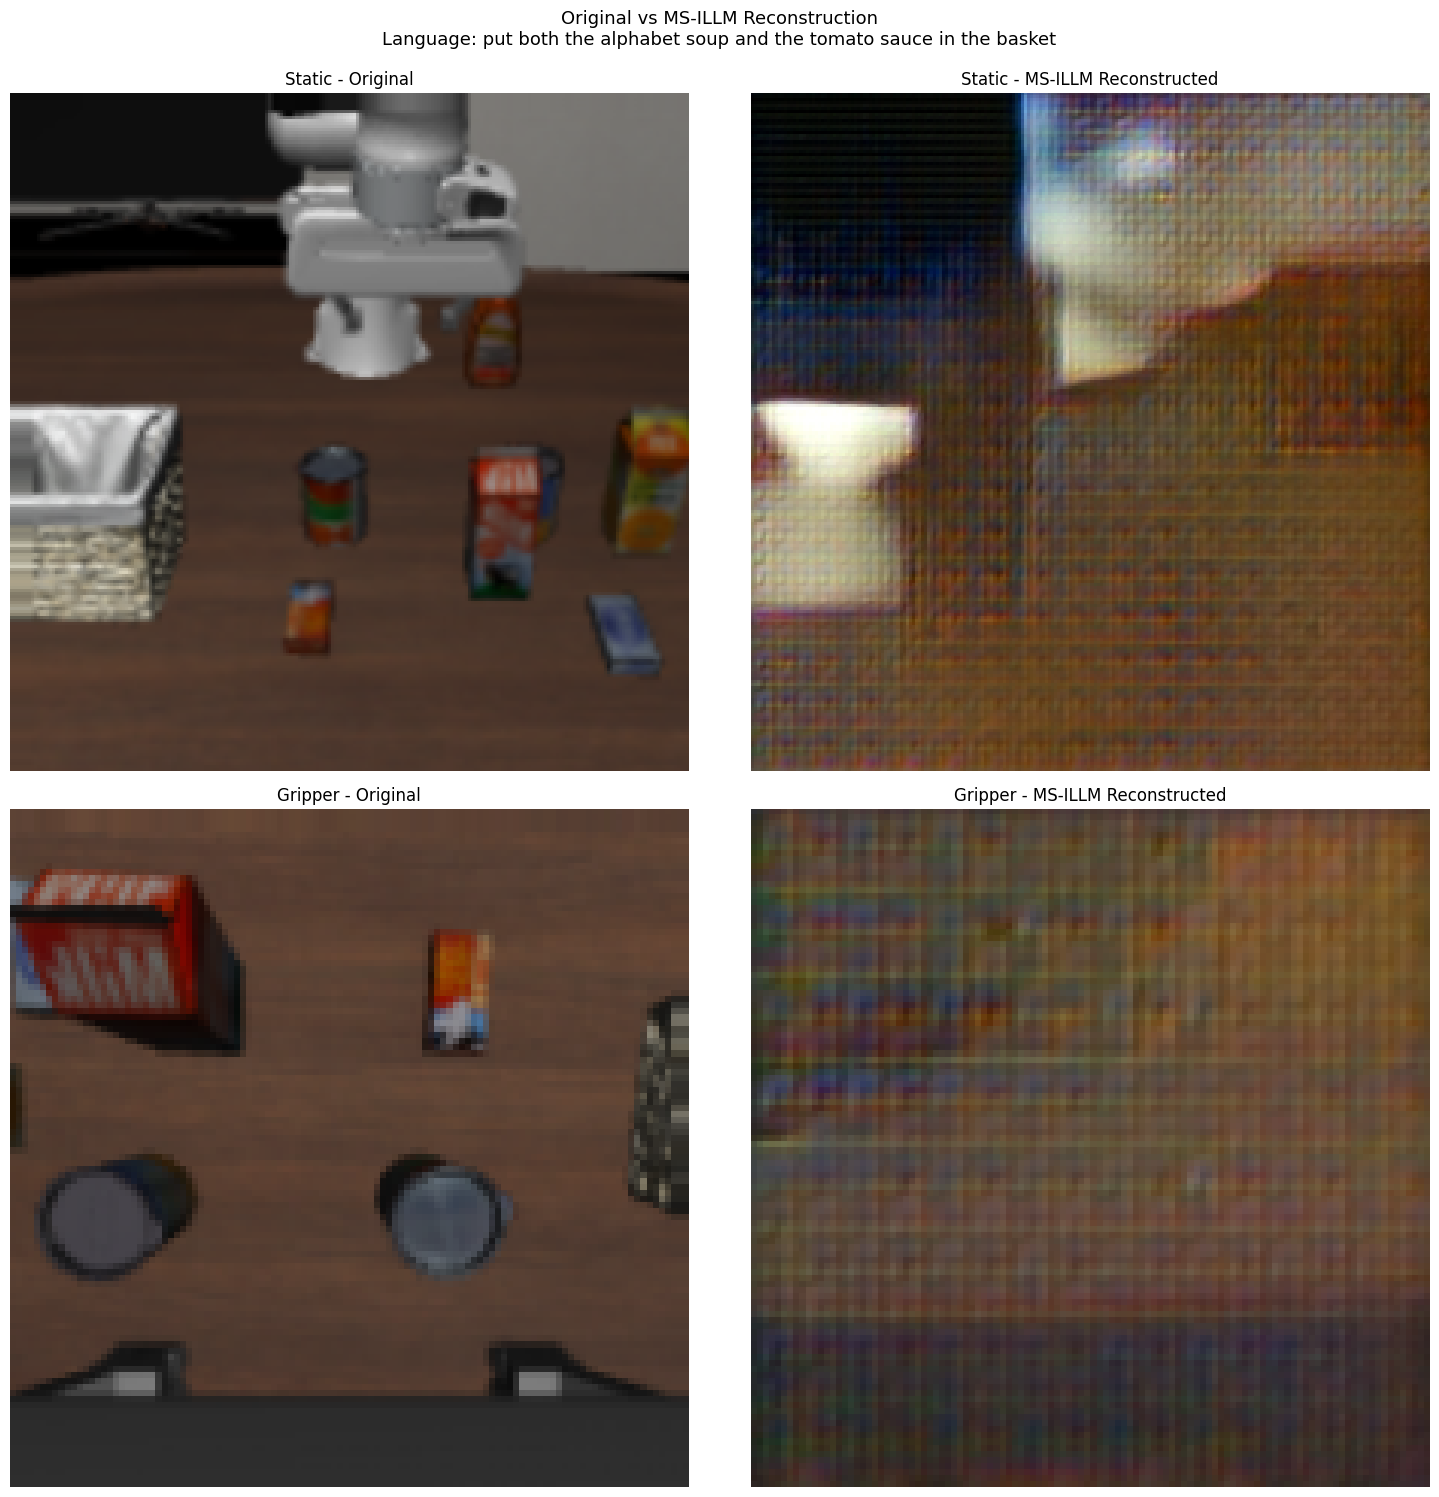


Visualizing SAM3 on compressed reconstructions...


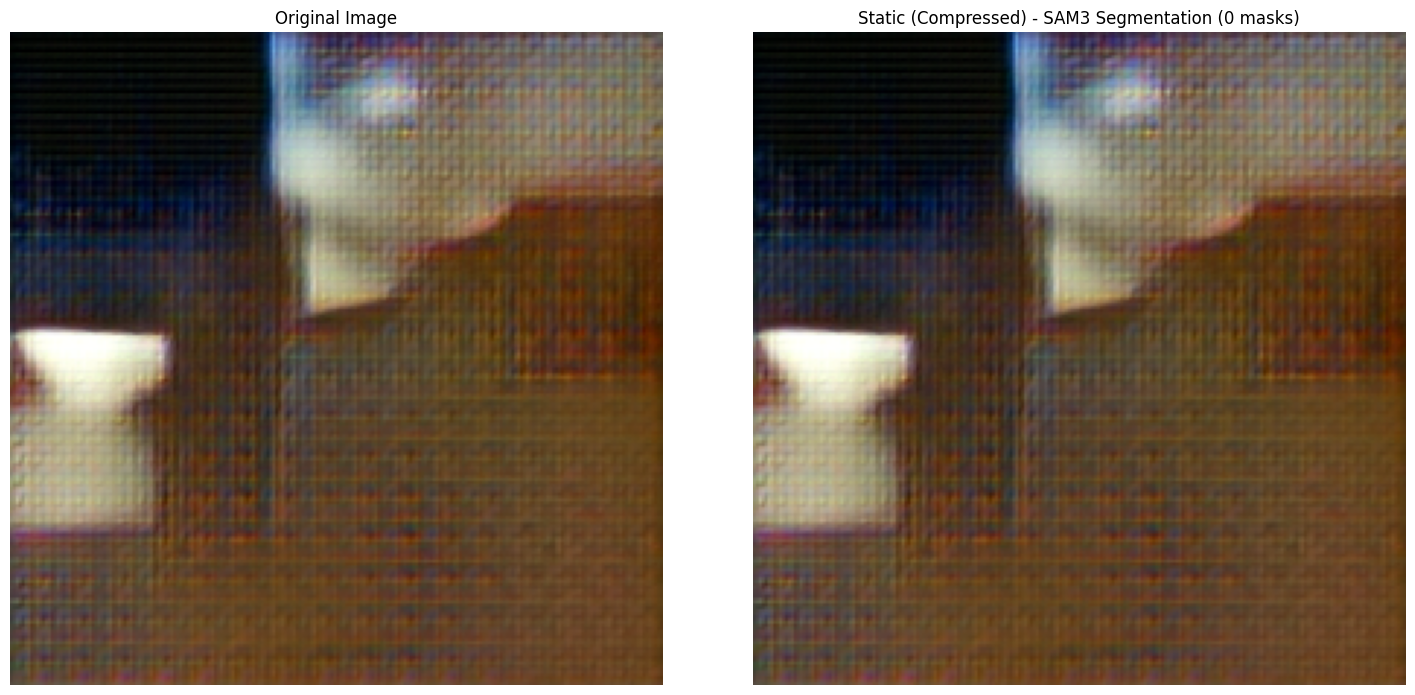

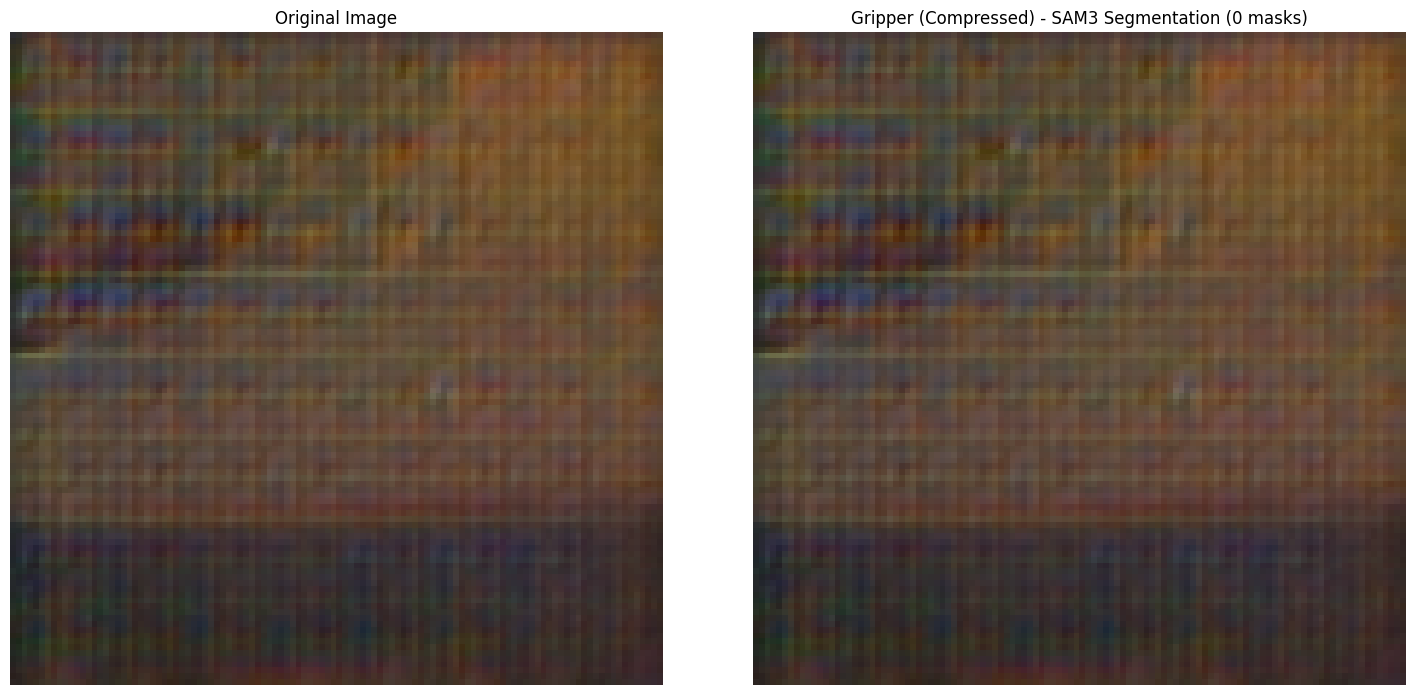


✓ Visualization completed!


In [ ]:
# Visualize SAM3 segmentation results
if sam3_available and sam3_processor is not None:
    def visualize_sam3_results(image_pil, masks, boxes, scores, title="SAM3 Segmentation"):
        """Visualize SAM3 segmentation results"""
        # Convert PIL to numpy for visualization
        img_np = np.array(image_pil)
        
        # Create figure
        fig, axes = plt.subplots(1, 2, figsize=(15, 7))
        
        # Original image
        axes[0].imshow(img_np)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # Segmented image
        axes[1].imshow(img_np)
        
        # Overlay masks
        if masks is not None and len(masks) > 0:
            # Convert masks to numpy if they're tensors
            if isinstance(masks, torch.Tensor):
                masks_np = masks.cpu().numpy()
            else:
                masks_np = masks
            
            # Create colored overlay
            overlay = img_np.copy()
            colors = plt.cm.tab20(np.linspace(0, 1, len(masks_np)))
            
            for i, (mask, score) in enumerate(zip(masks_np, scores)):
                # Apply mask with transparency
                color = (colors[i][:3] * 255).astype(np.uint8)
                # Squeeze out any extra dimensions (masks may have shape (1, H, W) or (H, W))
                mask = np.squeeze(mask)
                mask_bool = mask.astype(bool)
                overlay[mask_bool] = (overlay[mask_bool] * 0.5 + color * 0.5).astype(np.uint8)
            
            axes[1].imshow(overlay)
            
            # Draw bounding boxes
            if boxes is not None and len(boxes) > 0:
                if isinstance(boxes, torch.Tensor):
                    boxes_np = boxes.cpu().numpy()
                else:
                    boxes_np = boxes
                
                for i, (box, score) in enumerate(zip(boxes_np, scores)):
                    # Box format: [x1, y1, x2, y2] or [x, y, w, h]
                    if len(box) == 4:
                        if box[2] > box[0] and box[3] > box[1]:  # x1, y1, x2, y2
                            x1, y1, x2, y2 = box
                        else:  # x, y, w, h
                            x1, y1, w, h = box
                            x2, y2 = x1 + w, y1 + h
                        
                        rect = plt.Rectangle(
                            (x1, y1), x2 - x1, y2 - y1,
                            fill=False, edgecolor=colors[i], linewidth=2
                        )
                        axes[1].add_patch(rect)
                        axes[1].text(x1, y1 - 5, f"{score:.2f}", 
                                   color=colors[i], fontsize=10, weight='bold')
        
        axes[1].set_title(f"{title} ({len(masks) if masks is not None else 0} masks)")
        axes[1].axis('off')
        
        plt.tight_layout()
        return fig
    
    # Visualize static image results
    if masks_static is not None:
        print("\nVisualizing static image segmentation results...")
        fig_static = visualize_sam3_results(
            static_pil, masks_static, boxes_static, scores_static,
            title="Static Image - SAM3 Segmentation"
        )
        plt.show()
    
    # Visualize gripper image results
    if masks_gripper is not None:
        print("\nVisualizing gripper image segmentation results...")
        fig_gripper = visualize_sam3_results(
            gripper_pil, masks_gripper, boxes_gripper, scores_gripper,
            title="Gripper Image - SAM3 Segmentation"
        )
        plt.show()
    
    # Side-by-side comparison
    if masks_static is not None and masks_gripper is not None:
        print("\nCreating side-by-side comparison...")
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        
        # Static image - original
        axes[0, 0].imshow(static_pil)
        axes[0, 0].set_title("Static Image - Original")
        axes[0, 0].axis('off')
        
        # Static image - segmented
        static_np = np.array(static_pil)
        if len(masks_static) > 0:
            overlay_static = static_np.copy()
            colors = plt.cm.tab20(np.linspace(0, 1, len(masks_static)))
            masks_static_np = masks_static.cpu().numpy() if isinstance(masks_static, torch.Tensor) else masks_static
            for i, mask in enumerate(masks_static_np):
                color = (colors[i][:3] * 255).astype(np.uint8)
                # Squeeze out any extra dimensions (masks may have shape (1, H, W) or (H, W))
                mask = np.squeeze(mask)
                mask_bool = mask.astype(bool)
                overlay_static[mask_bool] = (overlay_static[mask_bool] * 0.5 + color * 0.5).astype(np.uint8)
            axes[0, 1].imshow(overlay_static)
        else:
            axes[0, 1].imshow(static_np)
        axes[0, 1].set_title(f"Static Image - SAM3 ({len(masks_static)} masks)")
        axes[0, 1].axis('off')
        
        # Gripper image - original
        axes[1, 0].imshow(gripper_pil)
        axes[1, 0].set_title("Gripper Image - Original")
        axes[1, 0].axis('off')
        
        # Gripper image - segmented
        gripper_np = np.array(gripper_pil)
        if len(masks_gripper) > 0:
            overlay_gripper = gripper_np.copy()
            colors = plt.cm.tab20(np.linspace(0, 1, len(masks_gripper)))
            masks_gripper_np = masks_gripper.cpu().numpy() if isinstance(masks_gripper, torch.Tensor) else masks_gripper
            for i, mask in enumerate(masks_gripper_np):
                color = (colors[i][:3] * 255).astype(np.uint8)
                # Squeeze out any extra dimensions (masks may have shape (1, H, W) or (H, W))
                mask = np.squeeze(mask)
                mask_bool = mask.astype(bool)
                overlay_gripper[mask_bool] = (overlay_gripper[mask_bool] * 0.5 + color * 0.5).astype(np.uint8)
            axes[1, 1].imshow(overlay_gripper)
        else:
            axes[1, 1].imshow(gripper_np)
        axes[1, 1].set_title(f"Gripper Image - SAM3 ({len(masks_gripper)} masks)")
        axes[1, 1].axis('off')
        
        plt.suptitle(f"Language Instruction: {lang_text}", fontsize=14, y=0.995)
        plt.tight_layout()
        plt.show()

        # (NEW) Original vs compressed reconstruction + SAM3 on compressed
        if 'static_comp_pil' in globals() and static_comp_pil is not None:
            print("\nCreating original vs compressed comparison...")

            fig, axes = plt.subplots(2, 2, figsize=(15, 15))

            axes[0, 0].imshow(static_pil)
            axes[0, 0].set_title("Static - Original")
            axes[0, 0].axis('off')

            axes[0, 1].imshow(static_comp_pil)
            axes[0, 1].set_title("Static - MS-ILLM Reconstructed")
            axes[0, 1].axis('off')

            axes[1, 0].imshow(gripper_pil)
            axes[1, 0].set_title("Gripper - Original")
            axes[1, 0].axis('off')

            axes[1, 1].imshow(gripper_comp_pil)
            axes[1, 1].set_title("Gripper - MS-ILLM Reconstructed")
            axes[1, 1].axis('off')

            plt.suptitle(f"Original vs MS-ILLM Reconstruction\nLanguage: {lang_text}", fontsize=13, y=0.995)
            plt.tight_layout()
            plt.show()

            if 'masks_static_comp' in globals() and masks_static_comp is not None:
                print("\nVisualizing SAM3 on compressed reconstructions...")

                _ = visualize_sam3_results(
                    static_comp_pil,
                    masks_static_comp,
                    boxes_static_comp,
                    scores_static_comp,
                    title="Static (Compressed) - SAM3 Segmentation",
                )
                plt.show()

                _ = visualize_sam3_results(
                    gripper_comp_pil,
                    masks_gripper_comp,
                    boxes_gripper_comp,
                    scores_gripper_comp,
                    title="Gripper (Compressed) - SAM3 Segmentation",
                )
                plt.show()

        print("\n✓ Visualization completed!")
else:
    print("⚠ SAM3 is not available. Please initialize SAM3 in the previous cells.")
